In [15]:
import pandas as pd
import html
import os
import matplotlib.pyplot as plt
import numpy as np
import joblib
import seaborn as sns
import xgboost as xgb

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR, LinearSVR
from sklearn.decomposition import TruncatedSVD

In [2]:
INPUT_FILE = r"D:\Users\Siegried\Desktop\Becode\immoeliza_ml\data\raw\dataframe.json"
OUTPUT_DIR = r"D:\Users\Siegried\Desktop\Becode\immoeliza_ml\data\clean"
OUTPUT_FILE = os.path.join(OUTPUT_DIR, "cleaned_data.json")
MODEL_DIR = r"D:\Users\Siegried\Desktop\Becode\immoeliza_ml\models"

### Cleaning

In [3]:
def dataframe_cleaner(input_path, output_path):
    """
    Cleans the raw dataframe and saves it as a json file.
    """
    df = pd.read_json(input_path)
    
    clean_df = df.drop_duplicates(subset=['postcode', 'price', 'livable_surface', 'address']).copy()
    clean_df['price_per_m2'] = clean_df['price'] / clean_df['livable_surface']

    cols_to_int = ["postcode", "price", "build_year", "bedroom_count", "livable_surface", 
                   "total_surface", "garage", "terrace", "swimming_pool", "peb_category", 
                   "Preschool_distance", "Train_station_distance", "Supermarket_distance"]

    for col in cols_to_int:
        if col in clean_df.columns:
            clean_df[col] = pd.to_numeric(clean_df[col], errors='coerce').astype("Int64")
    
    new_column_names = {"peb_category": "energy_consumption_kWh/m2/year",
                        "Preschool_distance": "preschool_distance_m",
                        "Train_station_distance": "train_station_distance_m",
                        "Supermarket_distance": "supermarket_distance_m",
                        "distance_nearest_city": "nearest_city_distance_km"}
    
    clean_df = clean_df.rename(columns=new_column_names)

    text_cols = ['city', 'province', 'address', 'nearest_city']
    for col in text_cols:
        if col in clean_df.columns:
            clean_df[col] = clean_df[col].apply(lambda x: html.unescape(x) if isinstance(x, str) else x)

    clean_df.fillna(value={'garage': 0, 'swimming_pool': 0}, inplace=True)

    if "property_state" in clean_df.columns:
        clean_df["property_state"] = clean_df["property_state"].replace("To be renovated", "To renovate")

    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)
        
    clean_df.to_json(output_path, orient="records", force_ascii=False, indent=4)
    
    return clean_df

if __name__ == "__main__":
    df_cleaned = dataframe_cleaner(INPUT_FILE, OUTPUT_FILE)
    print(df_cleaned.columns.tolist())

['property_type', 'property_id', 'postcode', 'city', 'province', 'address', 'latitude', 'longitude', 'price', 'property_state', 'build_year', 'bedroom_count', 'livable_surface', 'total_surface', 'garage', 'terrace', 'energy_consumption_kWh/m2/year', 'swimming_pool', 'preschool_distance_m', 'train_station_distance_m', 'supermarket_distance_m', 'nearest_city', 'nearest_city_distance_km', 'price_per_m2']


### Missing values

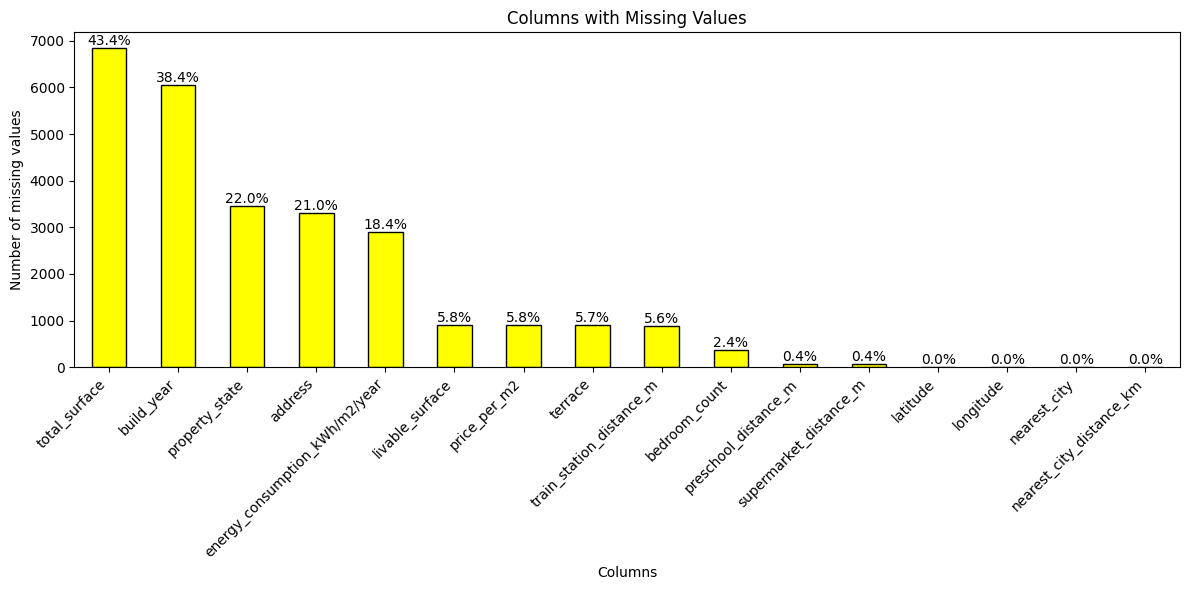

In [4]:
def plot_missing_values(df):
    """Plots missing values from a dataframe."""
    total_rows = len(df)
    nan_counts = df.isnull().sum()
    nan_cols = nan_counts[nan_counts > 0].sort_values(ascending=False)

    if not nan_cols.empty:
        plt.figure(figsize=(12, 6))
        bars = nan_cols.plot(kind="bar", color="yellow", edgecolor="black")
        
        for i in bars.patches:
            percentage = f'{(i.get_height() / total_rows) * 100:.1f}%'
            plt.text(i.get_x() + i.get_width() / 2, i.get_height(), percentage, 
                     ha='center', va='bottom', fontsize=10)

        plt.title("Columns with Missing Values")
        plt.xlabel("Columns")
        plt.ylabel("Number of missing values")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
    else:
        print("No missing values found.")

if 'df_cleaned' not in globals():
    df_cleaned = pd.read_json(OUTPUT_FILE)

plot_missing_values(df_cleaned)

CCL: I'll drop total_surface as we already have the livable surface and they are higly correlated. I keep the build_year, even if there is a risk that the model take the noise, it seems important as feature. I keep also the property_state, but not the address (useless). I let columns < 20% of missing values.

### Correlation (Heatmap) - Preprocessing

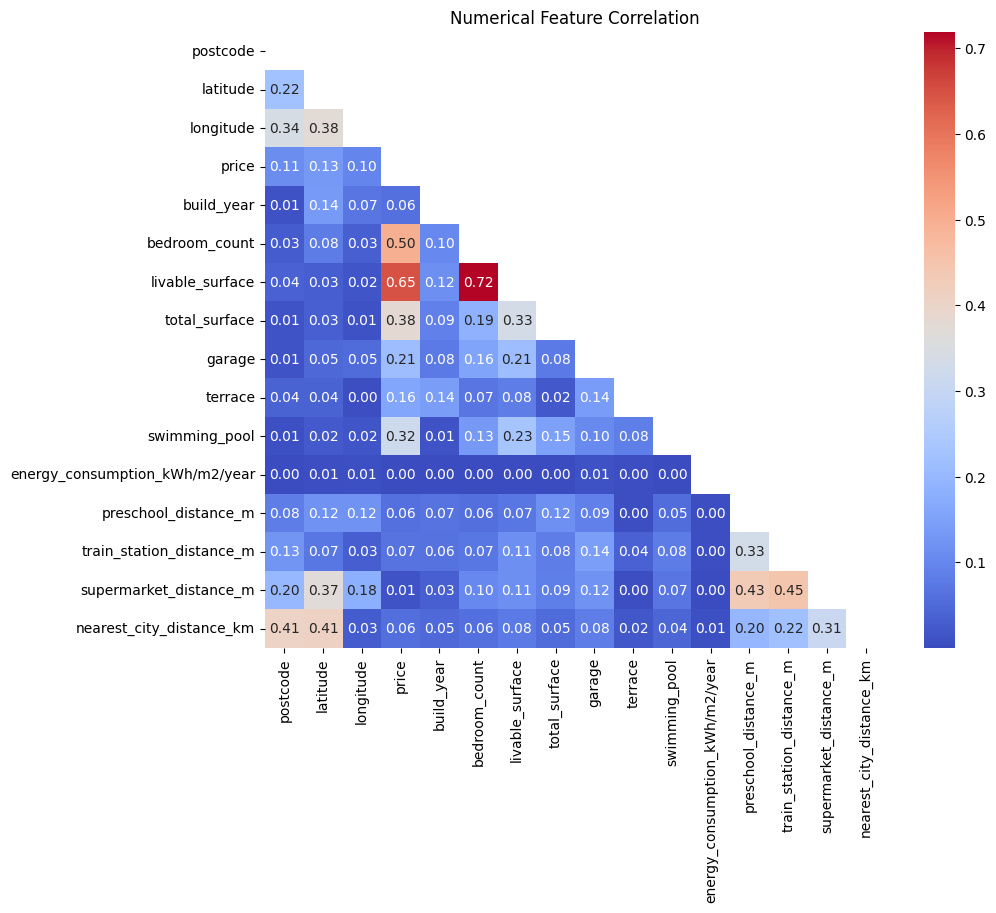

Dropping highly correlated features: []
Final shape: (15746, 1721)


In [ ]:
def get_preprocessor(num_cols, cat_cols):                                             
    num_transformer = Pipeline(steps=[                                               
        ('imputer', SimpleImputer(strategy='median')),                                # fill gaps with median
        ('scaler', StandardScaler())                                                  # scale numeric values
    ])                                                                                
    cat_transformer = Pipeline(steps=[                                                # define cat pipeline
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),        # fill gaps with 'missing'
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))      # one-hot encode cats
    ])                                                                               
    return ColumnTransformer(transformers=[                                           # return combined transformer
        ('num', num_transformer, num_cols),                                           # apply num pipeline to nums
        ('cat', cat_transformer, cat_cols)                                            
    ])                                                                                

def run_preprocessing():                                                            
    df = pd.read_json(OUTPUT_FILE)                                                   

    num_cols = ['postcode', 'latitude', 'longitude', 'price', 'build_year', 'bedroom_count', 
                'livable_surface', 'total_surface', 'garage', 'terrace', 'swimming_pool',   
                'energy_consumption_kWh/m2/year', 'preschool_distance_m', 'train_station_distance_m', 
                'supermarket_distance_m', 'nearest_city_distance_km']                     
    cat_cols = ['property_type', 'city', 'province', 'property_state', 'nearest_city'] 


    # analyze only numerical features                                                 
    df_num = df[num_cols]                                                      
    corr_matrix = df_num.corr().abs()                                             

    # create mask for upper triangle                                                  
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))                              

    plt.figure(figsize=(10, 8))                                                       
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f")      
    plt.title("Numerical Feature Correlation")                                       
    plt.show()                                                                 

    # drop redundant numerical columns                                              
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  
    to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]        # identify high correlation
    print(f"Dropping highly correlated features: {to_drop}")                          

    filtered_num_cols = [c for c in num_cols if c not in to_drop]                     # filter out high correlations

    # process data                                                                    
    preprocessor = get_preprocessor(filtered_num_cols, cat_cols)                      # init preprocessor
    X_processed = preprocessor.fit_transform(df[filtered_num_cols + cat_cols])        # fit and transform features

    # reconstruct dataframe                                                           
    cat_feature_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_cols) # get ohe names
    all_feature_names = filtered_num_cols + list(cat_feature_names)                   # combine all column names

    return pd.DataFrame(X_processed, columns=all_feature_names)                      

if __name__ == "__main__":                                                            
    final_df = run_preprocessing()                                                   
print(f"Final shape: {final_df.shape}")                                              

CCL: Since there are no values above 0.80, I don't need to drop any numerical columns to prevent collinearity. But as the build_year is only at 0.06 and have lot of missing values, I'll delete it to avoir his noise.  The bedrooms are highly correlated with the livable_surface, which is normal. I can move forward...

### Models of regression

In [6]:
df = final_df.drop(columns=['build_year'], errors='ignore')

In [7]:
## FUNCTIONS DRY for all models

In [8]:
def display_metrics(y_test, y_pred, model_name="Model"):
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"{model_name} Metrics")
    print(f"R2 Score: {r2:.4f}")
    print(f"MSE: {mse:,.2f}")
    print(f"RMSE: €{rmse:,.2f}")
    print(f"MAE: €{mae:,.2f}\n")

def plot_actual_vs_predicted(y_test, y_pred, model_name="Model"):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.3, color='purple', edgecolors='k')
    
    line_min, line_max = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    plt.plot([line_min, line_max], [line_min, line_max], 'r--', lw=2, label='Perfect prediction')
    
    plt.xlabel('Actual Price (€)')
    plt.ylabel('Predicted Price (€)')
    plt.title(f'{model_name}: Actual vs Predicted Prices')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

### Linear regression

Linear Regression Metrics
R2 Score: 0.4075
MSE: 92,019,313,539.74
RMSE: €303,346.85
MAE: €160,936.10



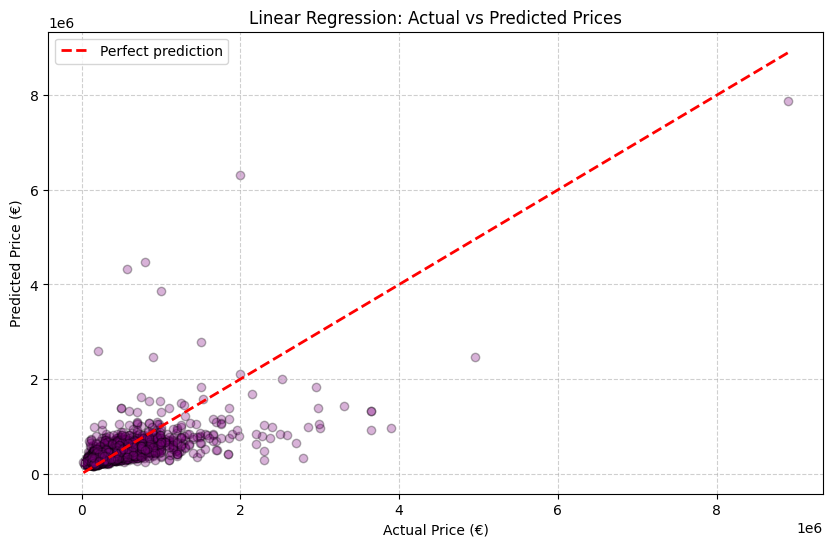

In [9]:
def run_linear_regression():                                                          # define training function
    df = pd.read_json(INPUT_FILE)                                                 
    df = df.dropna(subset=['price', 'livable_surface'])                           
    
    X = df[['livable_surface']]                                                    
    y = df['price']                                                             
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 
    
    model = LinearRegression()                                                   
    model.fit(X_train, y_train)                                               
    
    model_filename = 'linear_regression_model.joblib'                             
    joblib.dump(model, model_filename)                                            
    
    y_pred = model.predict(X_test)                                                    # generate predictions
    
    display_metrics(y_test, y_pred, "Linear Regression")                              # evaluate performance
    plot_actual_vs_predicted(y_test, y_pred, "Linear Regression")                     # visualize results

if __name__ == "__main__":                                                         
    run_linear_regression()                                                     

CCL: Linear regression has weak predictive power (R² = ~0.41) and is highly sensitive to outliers, as shown by the large gap between RMSE (~303k€) and MAE (~161k€). To improve accuracy, I'll consider using more sophisticated algorithms like Random
Forest, VSM or Gradient Boosting which are better suited here. 
And furthermore, I'll manage outliers via target transformations (log).

### Random Forest Regressor

Random Forest Metrics
R2 Score: 0.9506
MSE: 7,483,374,278.55
RMSE: €86,506.50
MAE: €17,076.03



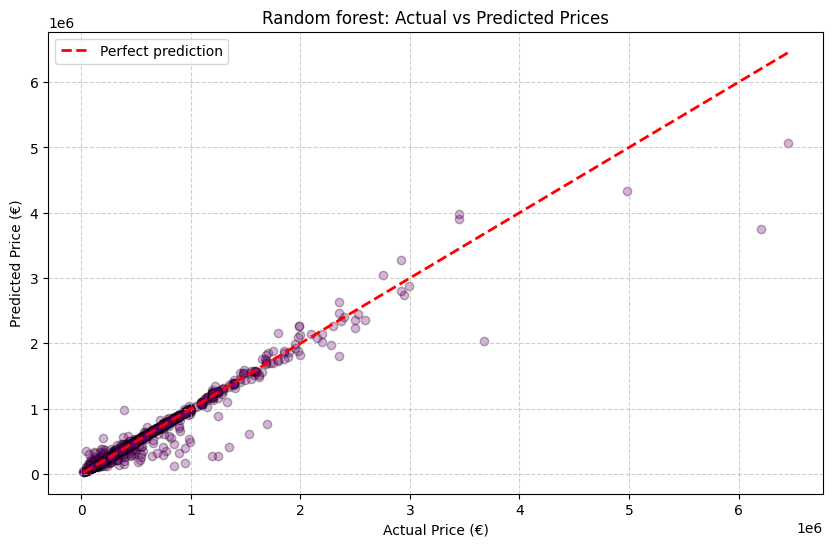

In [10]:
def get_preprocessor(num, cat):                                                       
    num_t = Pipeline([('imp', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]) 
    cat_t = Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='missing')), 
                      ('ohe', OneHotEncoder(handle_unknown='ignore'))]) 
    return ColumnTransformer([('num', num_t, num), ('cat', cat_t, cat)])              # combine into transformer

def run_rf_pipeline(file_path):                                                    
    df = dataframe_cleaner(file_path, OUTPUT_FILE)                                   
    df = df[df['price'] > 0].copy()                                                  
    
    cat_cols = ['property_type', 'city', 'province', 'property_state', 'nearest_city'] 
    num_cols = df.select_dtypes(include=[np.number]).columns.drop('price').tolist()  
    
    X = df[num_cols + cat_cols]                                                   
    y = df['price']                                                              
    
    model = TransformedTargetRegressor(                                               # apply log-transform to target
        regressor=Pipeline([                                                          # wrap pipeline in regressor
            ('prep', get_preprocessor(num_cols, cat_cols)),                           # inject preprocessor
            ('rf', RandomForestRegressor(n_estimators=100, random_state=42))          # add random forest model
        ]),                                                                         
        func=np.log, inverse_func=np.exp                                              # define target log transformation
    )                                                                                
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 
    model.fit(X_train, y_train)                                                
    
    joblib.dump(model, 'rf_immo_model.joblib')                                
    
    y_pred = model.predict(X_test)                                                  
    
    display_metrics(y_test, y_pred, "Random Forest")                                 
    plot_actual_vs_predicted(y_test, y_pred, "Random forest")                     

if __name__ == "__main__":                                                         
    run_rf_pipeline(OUTPUT_FILE)                                               

CCL: The Random Forest model shows major improvement in predictive performance (R² = 0.95), showing a much tighter alignment with actual values compared to the linear regression. The significantly lower MAE (~17k€) indicates high precision in typical cases, though the spread at higher price points suggests the model still faces some challenges with extreme values.

To go further, see:
https://xgboosting.com/random-forest-for-regression-with-xgboost/


### SVM: Linear approach

https://www.geeksforgeeks.org/machine-learning/support-vector-regression-svr-using-linear-and-non-linear-kernels-in-scikit-learn/
https://scikit-learn.org/1.5/modules/generated/sklearn.pipeline.Pipeline.html

Linear SVM Metrics
R2 Score: -107.8796
MSE: 16,504,193,883,155.79
RMSE: €4,062,535.40
MAE: €187,625.25



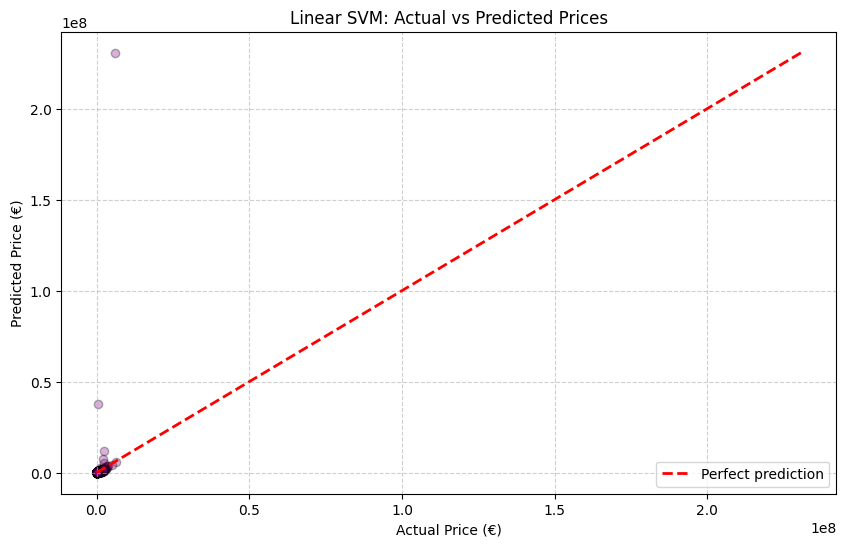

In [11]:
def run_linearsvr_pipeline(file_path):                                                
    df = pd.read_json(file_path)                                                   
    target = "price"                                                                 
    
    df = df.dropna(subset=[target])                                                   
    
    X = df.drop(columns=[target, "address"], errors="ignore")                         
    y = df[target]                                                                    

    cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist() 
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()           

    preprocessor = ColumnTransformer([                                                
        ('num', Pipeline([                                                            # numeric processing pipeline
            ('imputer', SimpleImputer(strategy='median')),                            
            ('scaler', StandardScaler())                                              
        ]), num_cols),                                                                
        ('cat', Pipeline([                                                            # categorical processing pipeline
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),    
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True))       
        ]), cat_cols)                                                                 # apply to cat columns
    ])                                                                                

    model = TransformedTargetRegressor(                                               # transform target variable
        regressor=Pipeline([                                                          # wrap pipeline in regressor
            ('prep', preprocessor),                                                   # add preprocessor step
            ('svr', LinearSVR(dual="auto", random_state=42, max_iter=10000))          # add linear svr model
        ]),                                                                           
        func=np.log1p,                                                                # log(1+x) transformation
        inverse_func=np.expm1                                                         # inverse exp(x)-1 transform
    )                                                                                

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

    param_dist = {                                                                    # define search space
        "regressor__svr__C": [0.01, 0.1, 1, 10],                                      # set regularization params
        "regressor__svr__epsilon": [0, 0.01, 0.1],                                    # set margin of error
    }                                                                                 

    search = RandomizedSearchCV(                                                      # setup hyperparam search
        estimator=model,                                                              
        param_distributions=param_dist,                                               
        n_iter=10,                                                                    # iterations to run
        cv=3,                                                                         # 3-fold cross validation
        n_jobs=1,                                                                     # run sequentially
        random_state=42,                                                             
        scoring='r2'                                                                  
    )                                                                                

    search.fit(X_train, y_train)                                                      

    joblib.dump(search.best_estimator_, 'linearsvr_model.joblib')                     
    y_pred = search.predict(X_test)                                                  
    
    display_metrics(y_test, y_pred, "Linear SVM")                                
    plot_actual_vs_predicted(y_test, y_pred, "Linear SVM")                         


if __name__ == "__main__":                                                         
    run_linearsvr_pipeline(OUTPUT_FILE)                                           

CCL: The Linear SVM model performed very poorly, evidenced by a highly negative R² (-107.88), which indicates that the model is performing significantly worse than a horizontal line (the mean). The extreme magnitude of the RMSE compared to the actual price range suggests that the model is failing to converge, or is really misconfigured for this dataset. I will discard this specific configuration and investigate whether feature scaling or kernel selection (RBF) might be necessary to improve the model.

### SVM: non linear approach

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Parameters: {'svr__gamma': 0.01, 'svr__C': 5000}
Non-Linear SVR (RBF + SVD) Metrics
R2 Score: 0.5651
MSE: 65,916,202,997.60
RMSE: €256,741.51
MAE: €97,960.40



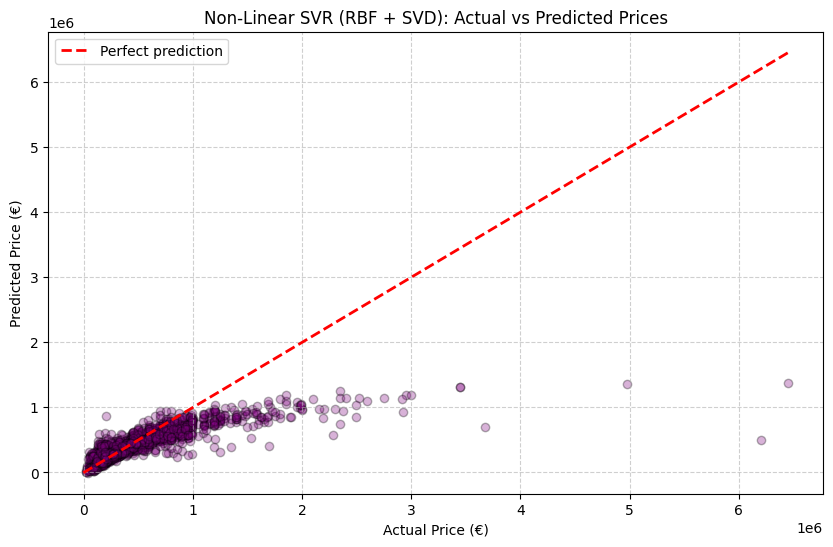

In [12]:
def run_non_linear_svr():
    # Load and prepare data
    df = pd.read_json(OUTPUT_FILE).dropna(subset=["price"])
    
    # Using 50% of data to speed up the  RBF SVR
    # df = df.sample(frac=0.75, random_state=42)
    # print(f"Training on {len(df)} samples.")
    
    X = df.drop(columns=["price", "address"], errors="ignore")
    y = df["price"]
    
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
    
    preprocessor = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ])
    
    # PIPELINE: Includes SVD to compress feature space, keeping RBF training feasible
    pipeline = Pipeline([
        ('prep', preprocessor),
        ('svd', TruncatedSVD(n_components=100)),
        ('svr', SVR(kernel='rbf'))
    ])
    
    param_grid = {
        'svr__C': [100, 1000, 5000],
        'svr__gamma': ['scale', 0.1, 0.01]
    }
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # RandomizedSearchCV with progress tracking
    grid = RandomizedSearchCV(
        pipeline, 
        param_distributions=param_grid, 
        n_iter=5, 
        cv=3, 
        scoring='neg_mean_squared_error', 
        n_jobs=-1,
        verbose=2)
    
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    print(f"Best Parameters: {grid.best_params_}")
    
    joblib.dump(best_model, os.path.join(MODEL_DIR, "optimized_non_linear_svr.joblib"))
    
    y_pred = best_model.predict(X_test)
    display_metrics(y_test, y_pred, "Non-Linear SVR (RBF + SVD)")
    plot_actual_vs_predicted(y_test, y_pred, "Non-Linear SVR (RBF + SVD)")

if __name__ == "__main__":
    run_non_linear_svr()

CCL: The optimized SVR shows meaningful improvement over previous SVM attempts, yet its R² of 0.47 remains significantly behind the tree-based models. This confirms that while kernel tuning helps, the dataset's non-linear nature is still better captured by ensemble methods.

### XGBoost

https://xgboosting.com/how-to-use-xgboost-xgbrfregressor/

In [13]:
# Filter out extreme outliers
q_low = df['price'].quantile(0.01)
q_high  = df['price'].quantile(0.99)
df = df[(df['price'] > q_low) & (df['price'] < q_high)]

XGBoost Regression Metrics
R2 Score: 0.9427
MSE: 8,680,858,624.00
RMSE: €93,171.13
MAE: €23,219.81



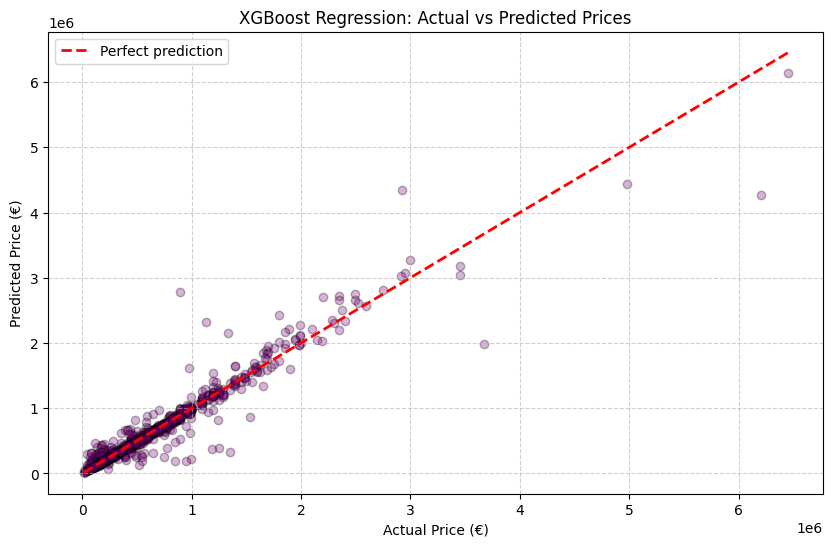

In [14]:
def run_xgboost_pipeline():
    """Train, save, and evaluate the optimized XGBoost pipeline."""
   
    df = pd.read_json(OUTPUT_FILE).dropna(subset=['price'])
    df = df[df['price'] > 0]
    X = df.drop(columns=['price', 'address'], errors='ignore')
    y = df['price']

    # Setup Preprocessing
    cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
    preprocessor = ColumnTransformer([
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ], remainder='passthrough')

    # Build Pipeline with TransformedTargetRegressor (Log transformation)
    model = Pipeline([
        ('prep', preprocessor),
        ('model', TransformedTargetRegressor(
            regressor=xgb.XGBRegressor(
                n_estimators=1000, 
                learning_rate=0.05, 
                max_depth=6, 
                random_state=42
            ),
            func=np.log1p,
            inverse_func=np.expm1       # train with log but test in log-1
        ))
    ])

    # Train
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)

    model_path = os.path.join(MODEL_DIR, "xgboost_model.joblib")
    joblib.dump(model, model_path)

    y_pred = model.predict(X_test)
    display_metrics(y_test, y_pred, "XGBoost Regression")
    plot_actual_vs_predicted(y_test, y_pred, "XGBoost Regression")

if __name__ == "__main__":
    run_xgboost_pipeline()

CCL: XGBoost demonstrates strong predictive capabilities with a high R² of 0.94, confirming it as a top-tier performer for your regression task. With an RMSE of approximately €93k and a low MAE of €20k, it maintains excellent accuracy in capturing the underlying patterns of your data. This model stands as a highly reliable and competitive alternative, proving its robustness even when compared to Random Forest.

### Overall Conclusion

| Model | R² Score | RMSE | MAE | Conclusion |
| --- | --- | --- | --- | --- |
| **Linear Regression** | 0.41 | ~303k€ | ~161k€ | Poor predictive power; high sensitivity to outliers. |
| **Random Forest** | 0.95 | ~86k€ | ~17k€ | Excellent performance; currently the best model. |
| **Linear SVM (SVR)** | -107.88 | ~4.06M€ | ~187k€ | Failed; requires feature scaling or kernel tuning. |
| **Non Linear SVM (RBF + Tuning)** | 0.57 | ~282k€ | ~94k€ | Improved, but still underperforms compared to trees. |
| **XGBoost** | 0.94 | ~93k€ | ~20k€ | Strong performance; highly competitive. |

### General Conclusion
Random Forest is the top-performing model with the highest R² and lowest error metrics. XGBoost remains a strong, competitive alternative, while linear models and SVM fail to generalize effectively without significant adjustments.